In [1]:
# !pip install fancy-einsum transformer-lens transformers


In [2]:
# !pip install torchtyping


In [3]:
# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import tqdm.notebook as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

from torchtyping import TensorType as TT
from typing import List, Union, Optional, Callable
from functools import partial
import copy
import itertools
import json

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML, Markdown

In [2]:
from transformers import BitsAndBytesConfig

# MODEL_NAME = "Qwen/QwQ-32B-Preview"
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cuda:0",
    quantization_config=BitsAndBytesConfig(
        load_in_8bit=True,
    ),
)
model.eval()


/fsx/ubuntu/miniconda3/envs/task-vector/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/fsx/ubuntu/miniconda3/envs/task-vector/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): Lla

###
Match samples from the dataset that:

Contain those cues → label as corrupted

Don't → label as clean



In [23]:
clean_prompt = "2+2 ="
corrupted_prompt = "2+2 = 5"

target_answer = "4"  # with space for tokenizer match


In [4]:
def cache_hook(layer_name):
    def hook(module, input, output):
        print(f"[{layer_name}] input: {type(input)} with len {len(input)}")
        print(f"[{layer_name}] input[0] shape: {input[0].shape}")
        activation_cache[layer_name] = input[0].detach()
    return hook


def patch_hook(layer_name):
    def hook(module, input, output):
        return activation_cache[layer_name].to(input[0].device)
    return hook


def tokenize(text):
    return tokenizer(text, return_tensors="pt").to(model.device)

activation_cache = {}
clean_input = tokenize(clean_prompt)
corrupted_input = tokenize(corrupted_prompt)

target_token_id = tokenizer.encode(target_answer, add_special_tokens=False)[0]


In [5]:
# for i, layer in enumerate(model.model.layers):
#     h = layer.input_layernorm.register_forward_hook(cache_hook(f"layer_{i}"))
#     hooks.append(h)


In [6]:
# Register hooks to cache residual input at all layers
hooks = []
for i, layer in enumerate(model.model.layers):
    h = layer.input_layernorm.register_forward_hook(cache_hook(f"layer_{i}"))
    hooks.append(h)

# Forward clean input
with torch.no_grad():
    _ = model(**clean_input)

# Remove caching hooks
for h in hooks:
    h.remove()


[layer_0] input: <class 'tuple'> with len 1
[layer_0] input[0] shape: torch.Size([1, 7, 4096])
[layer_1] input: <class 'tuple'> with len 1
[layer_1] input[0] shape: torch.Size([1, 7, 4096])
[layer_2] input: <class 'tuple'> with len 1
[layer_2] input[0] shape: torch.Size([1, 7, 4096])
[layer_3] input: <class 'tuple'> with len 1
[layer_3] input[0] shape: torch.Size([1, 7, 4096])
[layer_4] input: <class 'tuple'> with len 1
[layer_4] input[0] shape: torch.Size([1, 7, 4096])
[layer_5] input: <class 'tuple'> with len 1
[layer_5] input[0] shape: torch.Size([1, 7, 4096])
[layer_6] input: <class 'tuple'> with len 1
[layer_6] input[0] shape: torch.Size([1, 7, 4096])
[layer_7] input: <class 'tuple'> with len 1
[layer_7] input[0] shape: torch.Size([1, 7, 4096])
[layer_8] input: <class 'tuple'> with len 1
[layer_8] input[0] shape: torch.Size([1, 7, 4096])
[layer_9] input: <class 'tuple'> with len 1
[layer_9] input[0] shape: torch.Size([1, 7, 4096])
[layer_10] input: <class 'tuple'> with len 1
[laye

In [7]:
scores = []

for i, layer in enumerate(model.model.layers):
    # Register patch hook
    h = layer.input_layernorm.register_forward_hook(patch_hook(f"layer_{i}"))
    
    with torch.no_grad():
        outputs = model(**corrupted_input)

    # Extract logits for the final token
    logits = outputs.logits[0, -1]  # shape: [vocab_size]
    prob = torch.softmax(logits, dim=-1)[target_token_id].item()
    scores.append(prob)

    h.remove()


In [21]:
from transformers import (
    AutoTokenizer,
    LlamaForCausalLM,
    PreTrainedTokenizer,
    TextStreamer,
)
def generate(
    inputs,
    model,
    tokenizer,
    stream=True,
    stream_callback=None,
    **kwargs,
):
    if isinstance(inputs, str):
        inputs = tokenizer(inputs, return_tensors="pt").to("cuda")

    class TextStreamerWithCallback(TextStreamer):
        def put(self, value):
            super().put(value)

            if stream_callback:
                stream_callback(self.tokenizer.decode(value[0], **self.decode_kwargs))

    streamer = TextStreamerWithCallback(tokenizer, skip_prompt=True) if stream else None

    with torch.inference_mode():
        return model.generate(
            # inputs,
            # prepend_bos=True,
            # **kwargs,
            **inputs,
            max_length=16384,
            streamer=streamer,
            stop_strings=["</think>"],
            tokenizer=tokenizer,
        )



# Input
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""

# input_text = tokenizer(input_text, return_tensors="pt").to("cuda")

# encoding = tokenizer(input_text, return_tensors="pt").to("cuda")
# tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

output_tokens = generate(input_text, model, tokenizer)
output_tokens


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Okay, so I have this problem about a ship traveling upstream and downstream on a river. I need to find the speed of the ship in still water and the speed of the river. Hmm, let me try to break it down step by step.

First, let me note down the given information:

- The ship has traveled 24 km upstream and 28 km downstream.
- The time taken for this journey is half an hour less than the time taken to travel 30 km upstream and 21 km downstream.
- Alternatively, the same time is half an hour more than the time taken to travel 15 km upstream and 42 km downstream.

Both the ship and the river move uniformly, so their speeds are constant. Let me denote:

- Let \( v \) be the speed of the ship in still water (km/h).
- Let \( u \) be the speed of the river (km/h).

When the ship is moving upstream, its effective speed relative to the ground is \( v - u \). When moving downstream, it's \( v + u \).

So, for the first part of the journey (24 km upstream and 28 km downstream), the time taken woul

tensor([[128000,    198,    567,  ...,   3500,    627, 128014]],
       device='cuda:0')

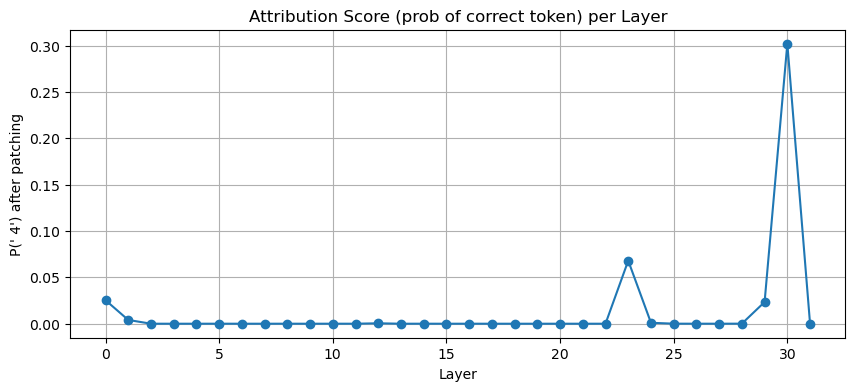

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(scores, marker='o')
plt.title("Attribution Score (prob of correct token) per Layer")
plt.xlabel("Layer")
plt.ylabel(f"P('{target_answer}') after patching")
plt.grid(True)
plt.show()


In [22]:
scores, target_answer

([0.0253753662109375,
  0.004062652587890625,
  1.627206802368164e-05,
  1.1324882507324219e-06,
  5.245208740234375e-06,
  2.0623207092285156e-05,
  6.139278411865234e-06,
  1.1920928955078125e-07,
  2.199411392211914e-05,
  1.7881393432617188e-07,
  2.3484230041503906e-05,
  1.1026859283447266e-05,
  0.00044989585876464844,
  4.76837158203125e-07,
  1.7821788787841797e-05,
  0.0,
  1.710653305053711e-05,
  0.0,
  2.384185791015625e-07,
  0.0,
  8.046627044677734e-06,
  0.0,
  7.033348083496094e-06,
  0.0679931640625,
  0.0010280609130859375,
  4.7266483306884766e-05,
  2.47955322265625e-05,
  2.1755695343017578e-05,
  6.186962127685547e-05,
  0.0233917236328125,
  0.302001953125,
  0.0],
 ' 4')